In [3]:
import json
import pandas as pd
import re
import os
from pathlib import Path
import time
import hashlib
from itertools import islice
import requests
import networkx as nx
from dotenv import load_dotenv
import  random
from itertools import islice
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx
from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from itertools import combinations
import hdbscan
import networkx as nx
import pandas as pd
import community as community_louvain 
from networkx.algorithms import community as nx_comm
import pandas as pd
import re
import leidenalg as la
import pandas as pd
import networkx as nx
import community as community_louvain
import igraph as ig
import leidenalg as la
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
import numpy as np






# STEP 5 : Dataset Partition Mục đích: Chia dữ liệu để huấn luyện và đánh giá

Vì các mô hình phân cụm là mô hình học ko giám sát nên ko cần phân cụm

---------------------------------------------------------------

# Step 6. Data Modelling

Mục đích: Thử nghiệm các thuật toán phân cụm khác nhau 


louvain, leiden, spectral clustering hybrid

In [20]:
df = pd.read_csv("data_users.csv", encoding="utf-8")

# --- Nodes ---
df[['steamid', 'personaname']].drop_duplicates()\
  .rename(columns={'steamid':'id','personaname':'label'})\
  .to_csv("nodes.csv", index=False, encoding="utf-8")

def parse_friends(x):
    if pd.isna(x): return []
    friends = []
    for f in str(x).split('|'):
        f = f.strip()
        if not f: 
            continue
        if re.fullmatch(r"[0-9eE\+\.-]+", f) and len(f) >= 10:
            try:
                friends.append(str(int(float(f))))
            except:
                continue
    return friends

# Edges 
edges = []
for _, r in df.iterrows():
    try:
        u = str(int(float(r['steamid'])))
    except:
        continue
    for f in parse_friends(r['friend_steamids_list']):
        if f != u:
            edges.append(tuple(sorted((u, f))))

edges = pd.DataFrame(set(edges), columns=['source','target'])
edges['weight'] = 1.0
edges.to_csv("edges.csv", index=False, encoding="utf-8")

print(f" {len(df)} node, {len(edges)} edge")


 1482 node, 57794 edge



 KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH

Louvain:
  • Modularity     : 0.1820
  • Số cụm phát hiện: 3

Leiden:
  • Modularity     : 0.1820
  • Số cụm phát hiện: 3

Spectral:
  • Modularity     : 0.0872
  • Số cụm phát hiện: 3

Hybrid:
  • Modularity     : 0.1112
  • Số cụm phát hiện: 9

BẢNG TỔNG HỢP:
           modularity  n_clusters
Louvain       0.1820         3.0
Leiden        0.1820         3.0
Spectral      0.0872         3.0
Hybrid        0.1112         9.0 



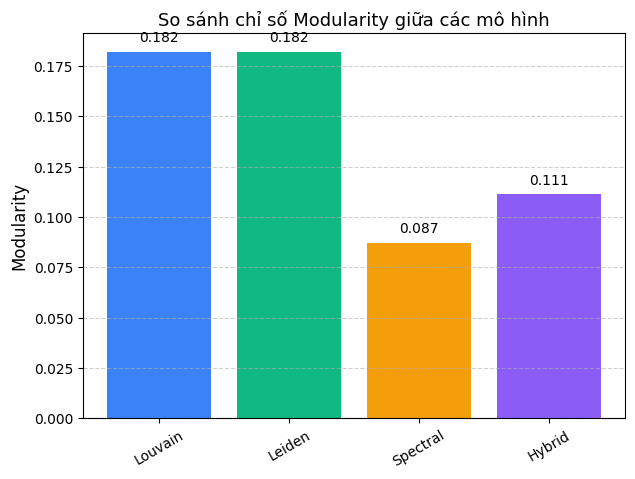

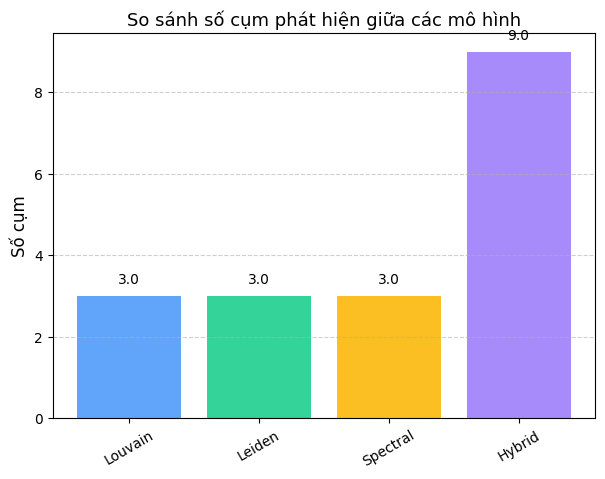

 Đã tạo xong các file xuất cho Gephi:
  • nodes_with_clusters.csv  → mở cùng edges.csv trong Gephi
  • graph_with_clusters.gexf → mở trực tiếp trong Gephi


In [8]:
nodes = pd.read_csv("nodes.csv")
edges = pd.read_csv("edges.csv")
G = nx.from_pandas_edgelist(edges, "source", "target")

#2. MÔ HÌNH LOUVAIN 
louvain_partition = community_louvain.best_partition(G)
nx.set_node_attributes(G, louvain_partition, "louvain")
mod_louvain = community_louvain.modularity(louvain_partition, G)
n_louvain = len(set(louvain_partition.values()))

# 3. MÔ HÌNH LEIDEN 
ig_graph = ig.Graph.TupleList(edges.itertuples(index=False), directed=False)
leiden_partition = la.find_partition(ig_graph, la.ModularityVertexPartition)
leiden_labels = {ig_graph.vs[v]["name"]: i for i, part in enumerate(leiden_partition) for v in part}
nx.set_node_attributes(G, leiden_labels, "leiden")
mod_leiden = leiden_partition.modularity
n_leiden = len(set(leiden_labels.values()))

#  4. MÔ HÌNH SPECTRAL CLUSTERING 
A = nx.to_numpy_array(G)
spectral = SpectralClustering(
    n_clusters=n_louvain, affinity='precomputed', assign_labels='kmeans', random_state=42
)
spectral_labels = spectral.fit_predict(A)
spectral_partition = {node: int(label) for node, label in zip(G.nodes(), spectral_labels)}
nx.set_node_attributes(G, spectral_partition, "spectral")

# Tính modularity cho Spectral
spectral_groups = [{n for n, c in spectral_partition.items() if c == i} for i in set(spectral_partition.values())]
mod_spectral = nx.algorithms.community.quality.modularity(G, spectral_groups)
n_spectral = len(spectral_groups)

#  5. MÔ HÌNH HYBRID (Louvain + Spectral )
hybrid_partition = {}
cluster_id = 0
for cid in set(louvain_partition.values()):
    comm_nodes = [n for n, c in louvain_partition.items() if c == cid]
    if len(comm_nodes) > 5:  # refine cụm lớn bằng spectral nhỏ
        subG = G.subgraph(comm_nodes)
        A_sub = nx.to_numpy_array(subG)
        n_sub = min(3, len(comm_nodes))
        spectral_sub = SpectralClustering(
            n_clusters=n_sub, affinity='precomputed', assign_labels='kmeans', random_state=42
        )
        labels_sub = spectral_sub.fit_predict(A_sub)
        for sub_label in np.unique(labels_sub):
            nodes_in_sub = [comm_nodes[i] for i, lab in enumerate(labels_sub) if lab == sub_label]
            for n in nodes_in_sub:
                hybrid_partition[n] = cluster_id
            cluster_id += 1
    else:
        for n in comm_nodes:
            hybrid_partition[n] = cluster_id
        cluster_id += 1
nx.set_node_attributes(G, hybrid_partition, "hybrid")

# Tính modularity cho Hybrid
hybrid_groups = [{n for n, c in hybrid_partition.items() if c == i} for i in set(hybrid_partition.values())]
mod_hybrid = nx.algorithms.community.quality.modularity(G, hybrid_groups)
n_hybrid = len(hybrid_groups)

# === 6. BẢNG TỔNG HỢP KẾT QUẢ ===
summary = {
    "Louvain": {"modularity": mod_louvain, "n_clusters": n_louvain},
    "Leiden": {"modularity": mod_leiden, "n_clusters": n_leiden},
    "Spectral": {"modularity": mod_spectral, "n_clusters": n_spectral},
    "Hybrid": {"modularity": mod_hybrid, "n_clusters": n_hybrid},
}
summary_df = pd.DataFrame(summary).T.round(4)

# 7. IN KẾT QUẢ ĐÁNH GIÁ
for model, info in summary.items():
    print(f"{model}:")
    print(f"  • Modularity     : {info['modularity']:.4f}")
    print(f"  • Số cụm phát hiện: {info['n_clusters']}\n")

print("BẢNG TỔNG HỢP:\n", summary_df, "\n")

#  8. BIỂU ĐỒ TRỰC QUAN HÓ
plt.figure(figsize=(7, 5))
plt.bar(summary_df.index, summary_df["modularity"], color=["#3b82f6", "#10b981", "#f59e0b", "#8b5cf6"])
plt.title("So sánh chỉ số Modularity giữa các mô hình", fontsize=13)
plt.ylabel("Modularity", fontsize=12)
plt.xticks(rotation=30)
for i, v in enumerate(summary_df["modularity"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(summary_df.index, summary_df["n_clusters"], color=["#60a5fa", "#34d399", "#fbbf24", "#a78bfa"])
plt.title("So sánh số cụm phát hiện giữa các mô hình", fontsize=13)
plt.ylabel("Số cụm", fontsize=12)
plt.xticks(rotation=30)
for i, v in enumerate(summary_df["n_clusters"]):
    plt.text(i, v + 0.3, str(v), ha='center', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 9. TẠO FILE GEPHI 
df_nodes = pd.DataFrame({
    "id": list(G.nodes()),
    "louvain": [G.nodes[n].get("louvain") for n in G.nodes()],
    "leiden": [G.nodes[n].get("leiden") for n in G.nodes()],
    "spectral": [G.nodes[n].get("spectral") for n in G.nodes()],
    "hybrid": [G.nodes[n].get("hybrid") for n in G.nodes()]
})

nodes_original = pd.read_csv("nodes.csv")

# Ép kiểu tránh lỗi merge
df_nodes["id"] = df_nodes["id"].astype(str)
nodes_original["id"] = nodes_original["id"].astype(str)

if "label" in nodes_original.columns:
    df_nodes = df_nodes.merge(nodes_original, on="id", how="left")

df_nodes.to_csv("nodes_clusters.csv", index=False, encoding="utf-8")
edges.to_csv("edges.csv", index=False, encoding="utf-8")
nx.write_gexf(G, "graph.gexf")
